<a href="https://colab.research.google.com/github/saramesa10/Algoritmos-de-Optimizaci-n/blob/main/AG2_Sara_Mesa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AG2 - Actividad Guiada 2
Nombre: Sara Mesa Rodríguez
Link:  https://colab.research.google.com/drive/1TxQTxFGxA2MnCZ3PYUTMfkbZm7vhaWCV?usp=sharingr>
Github: https://github.com/xxxxx/AlgoritmosOptimizacion
<br>




In [1]:
import math

##Programación Dinámica. Viaje por el rio
* **Definición**: Es posible dividir el problema en subproblemas más pequeños, guardando las soluciones para ser utilizadas más adelante.
* **Características** que permiten identificar problemas aplicables:<br>
  -Es posible almacenar soluciones de los subproblemas para ser utilizados más adelante<br>
  -Debe verificar el principio de optimalidad de Bellman: “en una secuencia optima de decisiones, toda sub-secuencia también es óptima” (*)<br>
  -La necesidad de guardar la información acerca de las soluciones parciales unido a la recursividad provoca la necesidad de preocuparnos por la complejidad espacial (cuantos recursos de espacio usaremos)<br>

###Problema<br>
En un río hay **n** embarcaderos y debemos desplazarnos río abajo desde un embarcadero a otro. Cada embarcadero tiene precios diferentes para ir de un embarcadero a otro situado más abajo. Para ir del embarcadero i al j, puede ocurrir que sea más barato hacer un trasbordo por un embarcadero intermedio k. El problema consiste en determinar la combinación más barata.

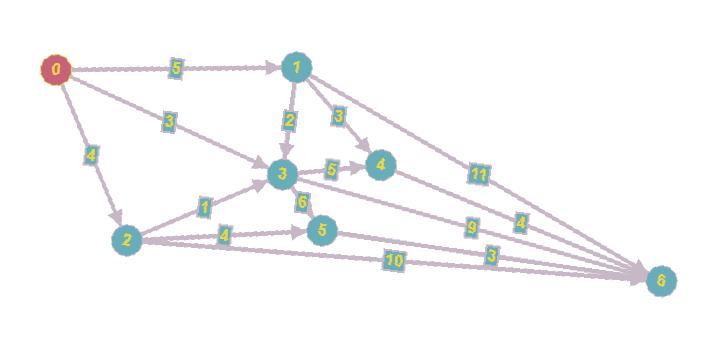

* Consideramos una tabla TARIFAS(i,j) para almacenar todos los precios que nos ofrecen los embarcaderos.<br>
* Si no es posible ir desde i a j daremos un valor alto para garantizar que ese trayecto no se va a elegir en la ruta óptima(modelado habitual para restricciones)

In [2]:
#Viaje por el rio - Programación dinámica
################################################################################

TARIFAS = [
[0,5,4,3,float("inf"),999,999],   #desde nodo 0
[999,0,999,2,3,999,11],  #desde nodo 1
[999,999, 0,1,999,4,10], #desde nodo 2
[999,999,999, 0,5,6,9],
[999,999, 999,999,0,999,4],
[999,999, 999,999,999,0,3],
[999,999,999,999,999,999,0]
]

#999 se puede sustituir por float("inf") del modulo math
TARIFAS

[[0, 5, 4, 3, inf, 999, 999],
 [999, 0, 999, 2, 3, 999, 11],
 [999, 999, 0, 1, 999, 4, 10],
 [999, 999, 999, 0, 5, 6, 9],
 [999, 999, 999, 999, 0, 999, 4],
 [999, 999, 999, 999, 999, 0, 3],
 [999, 999, 999, 999, 999, 999, 0]]

In [3]:
#Calculo de la matriz de PRECIOS y RUTAS
#  PRECIOS - contiene la matriz del mejor precio para ir de un nodo a otro
#  RUTAS   - contiene los nodos intermedios para ir de un nodo a otro
################################################################
def Precios(TARIFAS):
################################################################
  #Total de Nodos
  N = len(TARIFAS[0])

  #Inicialización de la tabla de precios
  PRECIOS = [ [9999]*N for i in [9999]*N]  #n x n
  RUTA = [ [""]*N for i in [""]*N]

  #Se recorren todos los nodos con dos bucles(origen - destino)
  #  para ir construyendo la matriz de PRECIOS
  for i in range(N-1):
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i

      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k
        PRECIOS[i][j] = MIN

  return PRECIOS,RUTA

In [4]:
PRECIOS,RUTA = Precios(TARIFAS)
#print(PRECIOS[0][6])

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
  print(RUTA[i])

PRECIOS
[9999, 5, 4, 3, 8, 8, 11]
[9999, 9999, 999, 2, 3, 8, 7]
[9999, 9999, 9999, 1, 6, 4, 7]
[9999, 9999, 9999, 9999, 5, 6, 9]
[9999, 9999, 9999, 9999, 9999, 999, 4]
[9999, 9999, 9999, 9999, 9999, 9999, 3]
[9999, 9999, 9999, 9999, 9999, 9999, 9999]

RUTA
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']


In [5]:
#Calculo de la ruta usando la matriz RUTA
def calcular_ruta(RUTA, desde, hasta):
  if desde == RUTA[desde][hasta]:
  #if desde == hasta:
    #print("Ir a :" + str(desde))
    return desde
  else:
    return str(calcular_ruta(RUTA, desde, RUTA[desde][hasta])) +  ',' + str(RUTA[desde][hasta])

print("\nLa ruta pasa por :")
print(calcular_ruta(RUTA, 0,6) )
print("Con valor" , PRECIOS[0][6])



La ruta pasa por :
0,2,5
Con valor 11


##Problema de Asignacion de tarea

In [56]:
#Asignacion de tareas - Ramificación y Poda
################################################################################
#    T A R E A
#   A
#   G
#   E
#   N
#   T
#   E

COSTES=[[11,12,18,40],
        [14,15,13,22],
        [11,17,19,23],
        [17,14,20,28]]


In [57]:
#Calculo del valor de una solucion parcial
def valor(S,COSTES):
  VALOR = 0
  for i in range(len(S)):
    VALOR += COSTES[S[i]][i]
  return VALOR



valor((0, 1, 2, 3  ),COSTES)

73

In [58]:
#Coste inferior para soluciones parciales
#  (1,3,) Se asigna la tarea 1 al agente 0 y la tarea 3 al agente 1

def CI(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += min( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

def CS(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += max( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

CI((0,1),COSTES)

68

In [59]:
#Genera tantos hijos como como posibilidades haya para la siguiente elemento de la tupla
#(0,) -> (0,1), (0,2), (0,3)
def crear_hijos(NODO, N):
  HIJOS = []
  for i in range(N ):
    if i not in NODO:
      HIJOS.append({'s':NODO +(i,)    })
  return HIJOS

In [60]:
crear_hijos((0,) , 4)

[{'s': (0, 1)}, {'s': (0, 2)}, {'s': (0, 3)}]

In [61]:
def ramificacion_y_poda(COSTES):
#Construccion iterativa de soluciones(arbol). En cada etapa asignamos un agente(ramas).
#Nodos del grafo  { s:(1,2),CI:3,CS:5  }
  #print(COSTES)
  DIMENSION = len(COSTES)
  MEJOR_SOLUCION=tuple( i for i in range(len(COSTES)) )
  CotaSup = valor(MEJOR_SOLUCION,COSTES)
  #print("Cota Superior:", CotaSup)

  NODOS=[]
  NODOS.append({'s':(), 'ci':CI((),COSTES)    } )

  iteracion = 0

  while( len(NODOS) > 0):
    iteracion +=1

    nodo_prometedor = [ min(NODOS, key=lambda x:x['ci']) ][0]['s']
    #print("Nodo prometedor:", nodo_prometedor)

    #Ramificacion
    #Se generan los hijos
    HIJOS =[ {'s':x['s'], 'ci':CI(x['s'], COSTES)   } for x in crear_hijos(nodo_prometedor, DIMENSION) ]

    #Revisamos la cota superior y nos quedamos con la mejor solucion si llegamos a una solucion final
    NODO_FINAL = [x for x in HIJOS if len(x['s']) == DIMENSION  ]
    if len(NODO_FINAL ) >0:
      #print("\n********Soluciones:",  [x for x in HIJOS if len(x['s']) == DIMENSION  ] )
      if NODO_FINAL[0]['ci'] < CotaSup:
        CotaSup = NODO_FINAL[0]['ci']
        MEJOR_SOLUCION = NODO_FINAL

    #Poda
    HIJOS = [x for x in HIJOS if x['ci'] < CotaSup   ]

    #Añadimos los hijos
    NODOS.extend(HIJOS)

    #Eliminamos el nodo ramificado
    NODOS =  [  x for x in NODOS if x['s'] != nodo_prometedor    ]

  print("La solucion final es:" ,MEJOR_SOLUCION , " en " , iteracion , " iteraciones" , " para dimension: " ,DIMENSION  )



ramificacion_y_poda(COSTES)

La solucion final es: [{'s': (1, 2, 0, 3), 'ci': 64}]  en  10  iteraciones  para dimension:  4


# ANÁLISIS PARA MEJORAR NOTA

In [74]:
#Asignacion de tareas
################################################################################
#    T A R E A
#   A
#   G
#   E
#   N
#   T
#   E

COSTES=[[11,12,18,40],
        [14,15,13,22],
        [11,17,19,23],
        [17,14,20,28]]


In [75]:
import time

def calcular_tiempo(func):
    def wrapper(*args, **kwargs):
        inicio = time.time()
        resultado = func(*args, **kwargs)
        fin = time.time()
        print("Tiempo de ejecución:", fin - inicio, "segundos")
        return resultado
    return wrapper


In [81]:
@calcular_tiempo
def ramificacion_y_poda(COSTES):
#Construccion iterativa de soluciones(arbol). En cada etapa asignamos un agente(ramas).
#Nodos del grafo  { s:(1,2),CI:3,CS:5  }
  #print(COSTES)
  DIMENSION = len(COSTES)
  MEJOR_SOLUCION=tuple( i for i in range(len(COSTES)) )
  CotaSup = valor(MEJOR_SOLUCION,COSTES)
  #print("Cota Superior:", CotaSup)

  NODOS=[]
  NODOS.append({'s':(), 'ci':CI((),COSTES)    } )

  iteracion = 0

  while( len(NODOS) > 0):
    iteracion +=1

    nodo_prometedor = [ min(NODOS, key=lambda x:x['ci']) ][0]['s']
    #print("Nodo prometedor:", nodo_prometedor)

    #Ramificacion
    #Se generan los hijos
    HIJOS =[ {'s':x['s'], 'ci':CI(x['s'], COSTES)   } for x in crear_hijos(nodo_prometedor, DIMENSION) ]

    #Revisamos la cota superior y nos quedamos con la mejor solucion si llegamos a una solucion final
    NODO_FINAL = [x for x in HIJOS if len(x['s']) == DIMENSION  ]
    if len(NODO_FINAL ) >0:
      #print("\n********Soluciones:",  [x for x in HIJOS if len(x['s']) == DIMENSION  ] )
      if NODO_FINAL[0]['ci'] < CotaSup:
        CotaSup = NODO_FINAL[0]['ci']
        MEJOR_SOLUCION = NODO_FINAL

    #Poda
    HIJOS = [x for x in HIJOS if x['ci'] < CotaSup   ]

    #Añadimos los hijos
    NODOS.extend(HIJOS)

    #Eliminamos el nodo ramificado
    NODOS =  [  x for x in NODOS if x['s'] != nodo_prometedor    ]

  #print("La solucion final es:" ,MEJOR_SOLUCION , " en " , iteracion , " iteraciones" , " para dimension: " ,DIMENSION  )
  return MEJOR_SOLUCION


ramificacion_y_poda(COSTES)

Tiempo de ejecución: 0.00018453598022460938 segundos


[{'s': (1, 2, 0, 3), 'ci': 64}]

In [80]:
import itertools

@calcular_tiempo
def fuerza_bruta(COSTES):
  # Representación de la solución será una tupla donde cada valor en la coordenada i-esima es la tarea asignado al agente i
  # Ejemplo (1,2,3,4) Tiene valor 11+15+19+28=73
  #
  # ¿Cuantas posibilidades hay? n! -> Complejidad factorial (exponencial)

  mejor_valor = 10e10
  mejor_solucion = ()

  for s in list(itertools.permutations(range(len(COSTES)))):
    #print(s, valor(s,COSTES))
    valor_tmp = valor(s,COSTES)
    if valor_tmp < mejor_valor:
      mejor_valor = valor_tmp
      mejor_solucion = s

 #print("La mejor solucion es:", mejor_solucion, " con valor:", mejor_valor)
  return mejor_solucion, mejor_valor
print(fuerza_bruta(COSTES))

Tiempo de ejecución: 3.314018249511719e-05 segundos
((0, 3, 1, 2), 61)


- **Generar matrices con valores aleatorios de mayores
dimensiones (5,6,7,…) y ejecutar ambos algoritmos.**


In [89]:
import numpy as np

# Generamos matrices con valores aleatorios de dimensión 5,6,7,8 y 9
COSTES_5 = np.random.randint(1, 50, size=(5, 5))
COSTES_6 = np.random.randint(1, 50, size=(6, 6))
COSTES_7 = np.random.randint(1, 50, size=(7, 7))
COSTES_8 = np.random.randint(1, 50, size=(8, 8))
COSTES_9 = np.random.randint(1, 50, size=(9, 9))
COSTES_10 = np.random.randint(1, 50, size=(10, 10))
COSTES_11 = np.random.randint(1, 50, size=(11, 11))
#print(COSTES_5)

In [90]:
##### DIMENSIÓN 5 #####
print('\n Dimensión 5')
# Ramificación y poda
print(ramificacion_y_poda(COSTES_5))
# Fuerza bruta
print(fuerza_bruta(COSTES_5))

##### DIMENSIÓN 6 #####
print('\n Dimensión 6')
# Ramificación y poda
print(ramificacion_y_poda(COSTES_6))
# Fuerza bruta
print(fuerza_bruta(COSTES_6))

##### DIMENSIÓN 7 #####
print('\n Dimensión 7')
# Ramificación y poda
print(ramificacion_y_poda(COSTES_7))
# Fuerza bruta
print(fuerza_bruta(COSTES_7))

##### DIMENSIÓN 8 #####
print('\n Dimensión 8')
# Ramificación y poda
print(ramificacion_y_poda(COSTES_8))
# Fuerza bruta
print(fuerza_bruta(COSTES_8))

##### DIMENSIÓN 9 #####
print('\n Dimensión 9')
# Ramificación y poda
print(ramificacion_y_poda(COSTES_9))
# Fuerza bruta
print(fuerza_bruta(COSTES_9))

##### DIMENSIÓN 10 #####
print('\n Dimensión 10')
# Ramificación y poda
print(ramificacion_y_poda(COSTES_10))
# Fuerza bruta
print(fuerza_bruta(COSTES_10))

##### DIMENSIÓN 11 #####
print('\n Dimensión 11')
# Ramificación y poda
print(ramificacion_y_poda(COSTES_11))
# Fuerza bruta
print(fuerza_bruta(COSTES_11))


 Dimensión 5
Tiempo de ejecución: 0.0007312297821044922 segundos
[{'s': (3, 2, 1, 0, 4), 'ci': np.int64(78)}]
Tiempo de ejecución: 0.0006334781646728516 segundos
((3, 2, 1, 0, 4), np.int64(78))

 Dimensión 6
Tiempo de ejecución: 0.006389617919921875 segundos
[{'s': (1, 5, 2, 3, 0, 4), 'ci': np.int64(65)}]
Tiempo de ejecución: 0.00197601318359375 segundos
((4, 5, 2, 0, 3, 1), np.int64(59))

 Dimensión 7
Tiempo de ejecución: 0.004643440246582031 segundos
[{'s': (1, 6, 2, 3, 5, 4, 0), 'ci': np.int64(43)}]
Tiempo de ejecución: 0.015842437744140625 segundos
((6, 0, 2, 3, 5, 4, 1), np.int64(43))

 Dimensión 8
Tiempo de ejecución: 0.0330204963684082 segundos
[{'s': (0, 4, 5, 7, 2, 6, 3, 1), 'ci': np.int64(87)}]
Tiempo de ejecución: 0.15403199195861816 segundos
((0, 7, 4, 6, 1, 2, 5, 3), np.int64(87))

 Dimensión 9
Tiempo de ejecución: 0.09340238571166992 segundos
[{'s': (2, 5, 4, 0, 7, 3, 1, 6, 8), 'ci': np.int64(62)}]
Tiempo de ejecución: 1.3688182830810547 segundos
((3, 6, 0, 5, 2, 1, 7, 4

- **¿A partir de que dimensión el algoritmo por fuerza
bruta deja de ser una opción?**

Como sabemos, la fuerza bruta explora todas las permutaciones posibles, por lo que su complejidad es: $n!$.

Como podemos observar, a partir de la **dimensión 10** el tiempo de ejecución es de **23.7s**  pero incrementa muchísimo con una **dimensión 11** donde el tiempo de ejecución es de 243.27s≈**4min**.

Así, la fuerza bruta deja de ser opción práctica a partir de **n = 10 o 11**, porque el tiempo se dispara exponencialmente.

- **¿Hay algún valor de la dimensión a partir de la cual el algoritmo de ramificación y poda también deja de ser una opción válida?**

In [92]:
COSTES_12 = np.random.randint(1, 50, size=(12, 12))

##### DIMENSIÓN 12 #####
print('\n Dimensión 12')
# Ramificación y poda
print(ramificacion_y_poda(COSTES_12))

COSTES_13 = np.random.randint(1, 50, size=(13, 13))

##### DIMENSIÓN 13 #####
print('\n Dimensión 13')
# Ramificación y poda
print(ramificacion_y_poda(COSTES_13))


 Dimensión 12
Tiempo de ejecución: 121.43016314506531 segundos
[{'s': (5, 3, 7, 6, 1, 8, 0, 2, 10, 9, 4, 11), 'ci': np.int64(103)}]

 Dimensión 13


KeyboardInterrupt: 

Como podemos observar, anteriormente ya habiamos visto que a partir de la **dimensión 11** el tiempo de ejecución es de **27s** pero incrementa muchísimo con una **dimensión 12** donde el tiempo de ejecución ya es de 121.43s≈**2min**. Intento probar con una matriz de **dimensión 13** pero pasan más de **10 min** y no termina de ejecutarse.

Así, la ramificación y poda en la práctica se vuelve inviable a partir de **n = 12 o 13**, porque no se logra obtener un resultado sin sobrepasar el minuto de ejecución.

##Descenso del gradiente

In [18]:
import math                      #Funciones matematicas
import matplotlib.pyplot as plt  #Generacion de gráficos (otra opcion seaborn)
import numpy as np               #Tratamiento matriz N-dimensionales y otras (fundamental!)
#import scipy as sc

import random

Vamos a buscar el minimo de la funcion paraboloide por le metodo del descenso del gradiente : $$f(x) =  x² + y²$$

Obviamente se encuentra en (x,y)=(0,0) pero probaremos como llegamos a él a través del descenso del gradiante.

In [19]:
#Definimos la funcion(f) y el gradiente(df)
#Paraboloide
f  = lambda X:      X[0]**2 + X[1]**2    #Funcion
df = lambda X: [2*X[0] , 2*X[1]]         #Gradiente

df([1,2])

[2, 4]

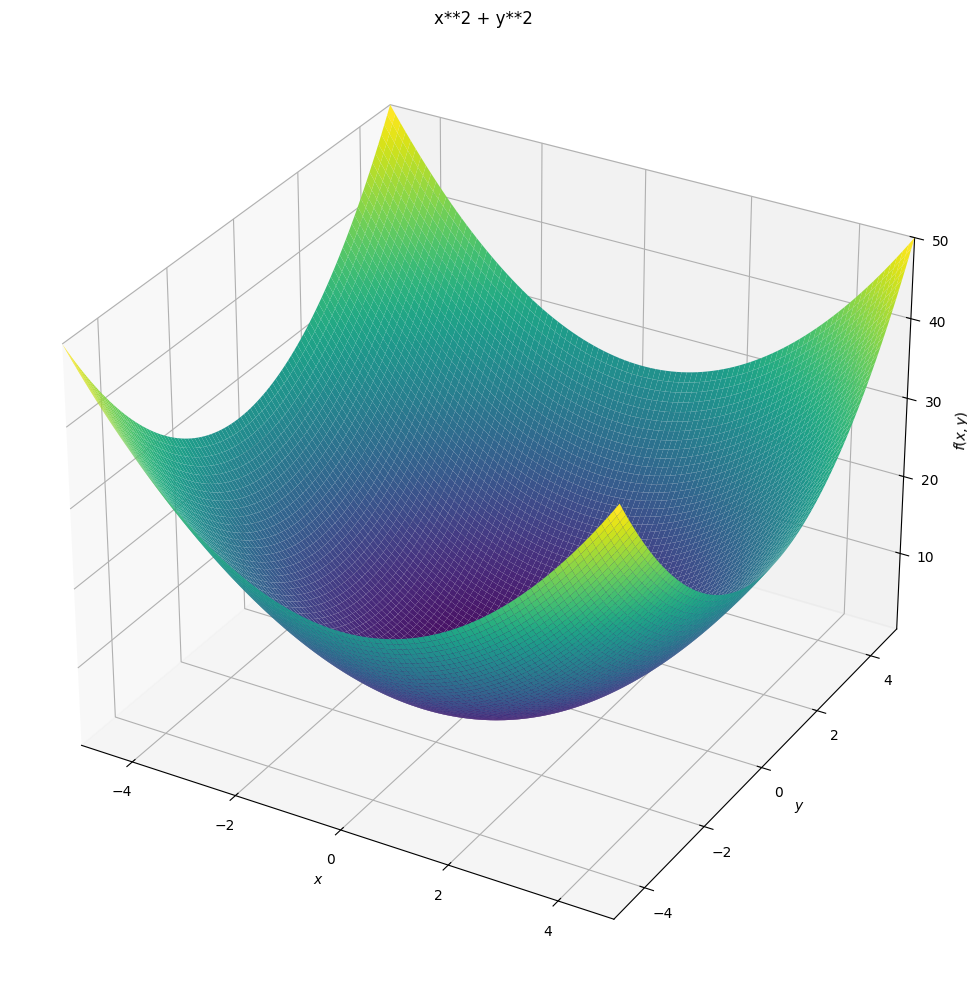

In [20]:
from sympy import symbols
from sympy.plotting import plot
from sympy.plotting import plot3d
x,y = symbols('x y')
plot3d(x**2 + y**2,
       (x,-5,5),(y,-5,5),
       title='x**2 + y**2',
       size=(10,10))

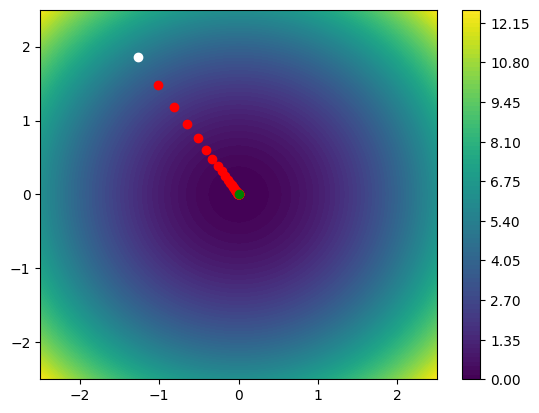

Solucion: [-1.8049032086703248e-05, 2.6464603866394107e-05] 1.0261428170720053e-09


In [21]:
#Prepara los datos para dibujar mapa de niveles de Z
resolucion = 100
rango=2.5

X=np.linspace(-rango,rango,resolucion)
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar()

#Generamos un punto aleatorio inicial y pintamos de blanco
P=[random.uniform(-2,2  ),random.uniform(-2,2 ) ]
plt.plot(P[0],P[1],"o",c="white")

#Tasa de aprendizaje. Fija. Sería más efectivo reducirlo a medida que nos acercamos.
TA=.1

#Iteraciones:500
for _ in range(50):
  grad = df(P)
  #print(P,grad)
  P[0],P[1] = P[0] - TA*grad[0] , P[1] - TA*grad[1]
  plt.plot(P[0],P[1],"o",c="red")

#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f(P))


**¿Te atreves a optimizar la función?:**

$$f(x)=sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - e^y)$$
<br>
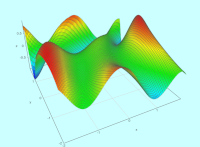


Vamos a buscar el mínimo de la función $f(x,y)=sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - e^y)$ por el método del descenso de gradiente.

Para ello, calculamos su gradiente: $∇f=(∂f/∂x,​∂f/∂y​​)$

$$∂f/∂x = cos(1/2 * x^2 - 1/4 * y^2 + 3)*x*cos(2*x + 1 - e^y)+sin(1/2 * x^2 - 1/4 * y^2 + 3)*(-sen(2*x + 1 - e^y))*2 = x*cos(2*x + 1 - e^y)*cos(1/2 * x^2 - 1/4 * y^2 + 3)-2*sen(2*x + 1 - e^y)*sin(1/2 * x^2 - 1/4 * y^2 + 3)$$

$$​∂f/∂y​ = cos(1/2 * x^2 - 1/4 * y^2 + 3)*(-1/2*y)*cos(2*x + 1 - e^y) + sin(1/2 * x^2 - 1/4 * y^2 + 3)*(-sen(2*x + 1 - e^y))*(-e^y) = (-1/2*y)*cos(2*x + 1 - e^y)*cos(1/2 * x^2 - 1/4 * y^2 + 3) + e^y*sen(2*x + 1 - e^y)*sin(1/2 * x^2 - 1/4 * y^2 + 3)$$

In [22]:
#Definimos la funcion
f= lambda X: math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) * math.cos(2*X[0] + 1 - math.exp(X[1]))
df = lambda X: [math.cos(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3)*X[0]*math.cos(2*X[0] + 1 - math.exp(X[1])) -2*math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3)*math.sin(2*X[0] + 1 - math.exp(X[1])),

                -1/2*X[1]*math.cos(2*X[0] + 1 - math.exp(X[1]))*math.cos(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) + math.exp(X[1])*math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3)*math.sin(2*X[0] + 1 - math.exp(X[1]))]

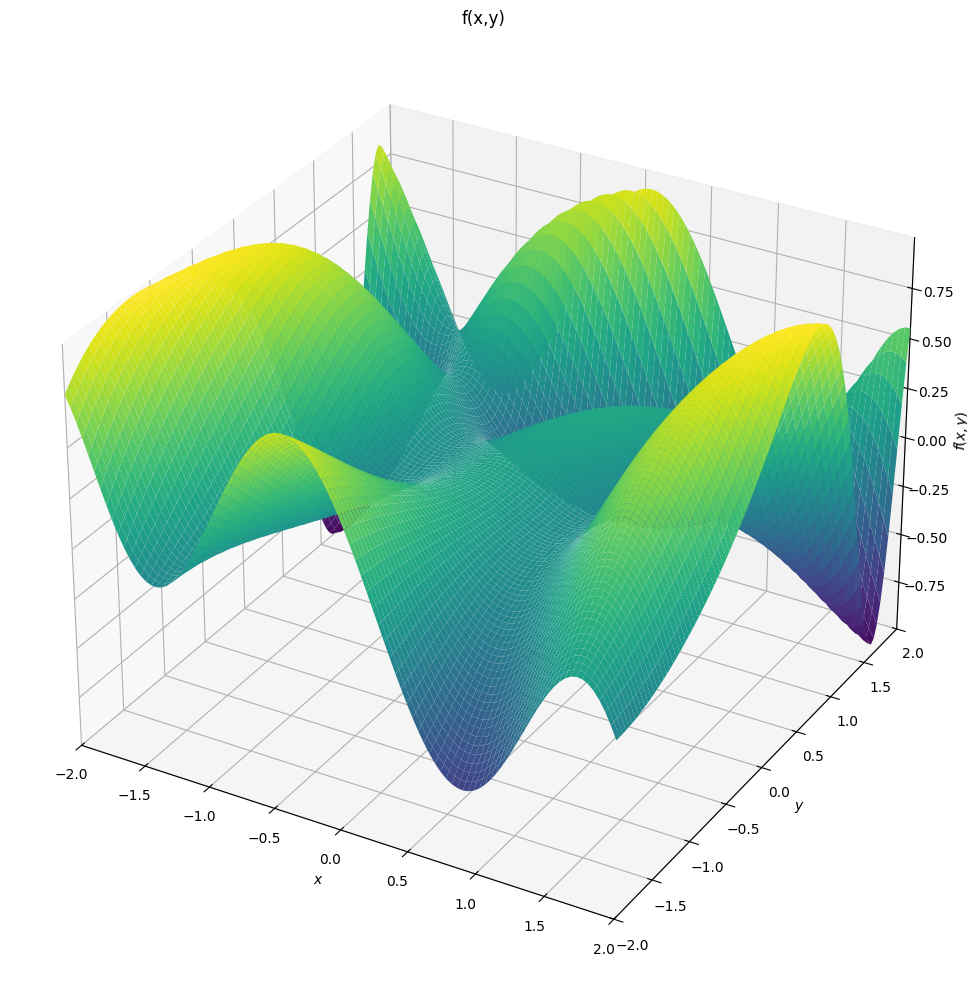

In [33]:
from sympy import symbols, sin, cos, exp
from sympy.plotting import plot
from sympy.plotting import plot3d
x,y = symbols('x y')
plot3d(sin(0.5 * x**2 - 0.25 * y**2 + 3) * cos(2*x + 1 - exp(y)),
       (x,-2,2),(y,-2,2),
       title='f(x,y)',
       size=(10,10))

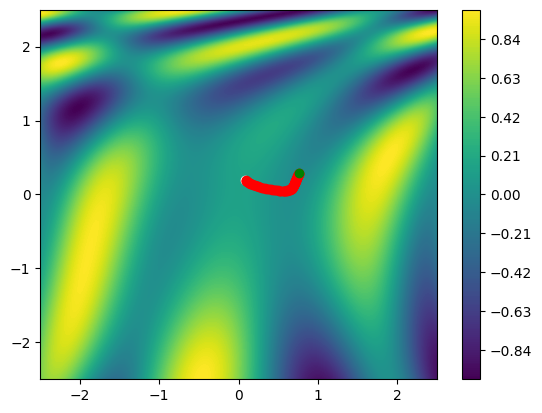

Solucion: [0.7608769537055534, 0.2883218136056567] -0.047394000233172216


In [42]:
#Prepara los datos para dibujar mapa de niveles de Z
resolucion = 200
rango=2.5

X=np.linspace(-rango,rango,resolucion)
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar()

#Generamos un punto aleatorio inicial y pintamos de blanco
P=[random.uniform(-2,2  ),random.uniform(-2,2 ) ]
plt.plot(P[0],P[1],"o",c="white")

#Tasa de aprendizaje. Fija. Sería más efectivo reducirlo a medida que nos acercamos.
TA=.05

#Iteraciones:100
for _ in range(100):
  grad = df(P)
  #print(P,grad)
  P[0],P[1] = P[0] - TA*grad[0] , P[1] - TA*grad[1]
  plt.plot(P[0],P[1],"o",c="red")

#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f(P))

Sabemos que la función $f(x,y)$ es no convexa y presenta múltiples extremos locales. Al aplicar el método del descenso del gradiente, el algoritmo converge correctamente, sin embargo, lo hace hacia un mínimo local que depende del punto inicial elegido. Esto confirma que, para funciones no convexas, el método del descenso por gradiente no garantiza la obtención del mínimo global y, por tanto, presenta limitaciones en problemas de optimización no convexos.

##Problema de Autobuses por Fuerza Bruta

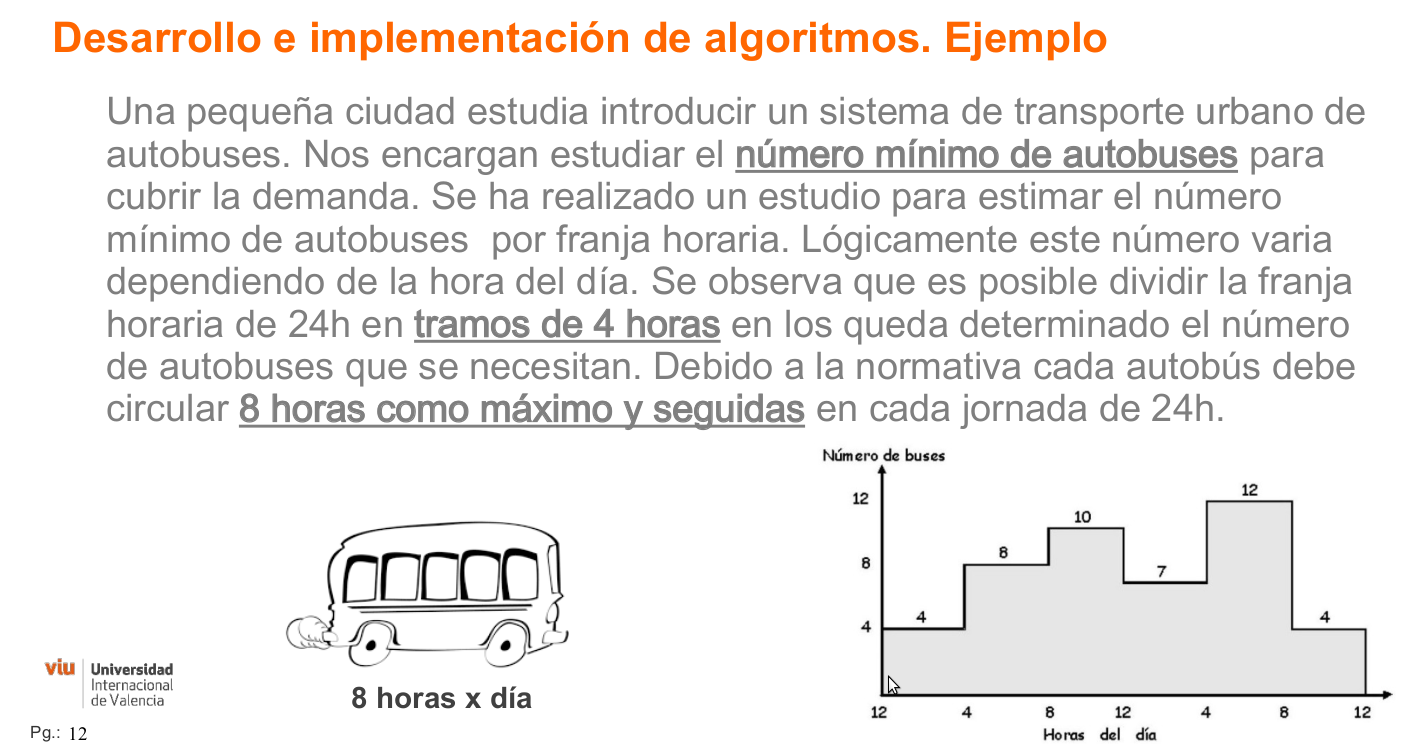

In [16]:
###################################################
# Ximo Sanz Tornero.
###################################################
from itertools import product

# Paso 1: Inicializamos los datos
# Demanda mínima de autobuses por tramo
demanda = [4, 8, 10, 7, 12, 4]  # d[0], d[1], ..., d[5]
tramos = len(demanda)  # Número de tramos (6 en este caso)


#Posible Solucion
x = [4,5,6,7,8,9]

for t in range(tramos):
    # Calculamos el número actual de autobuses que están cubriendo el tramo t
    cobertura_actual = x[t] + x[t - 1]  # Autobuses en t y t-1 (cíclico)

    # Si la cobertura actual es menor que la demanda, añadimos autobuses en t
    if cobertura_actual < demanda[t]:
        # Añadimos los autobuses necesarios en el tramo t
        x[t] += demanda[t] - cobertura_actual

#Función objetivo
f_objetivo = sum(x)


# Se crean funciones tanto para verificar posibles soluciones como para obtener el valor de la función objetivo de la solución
# Función objetivo: suma de todos los x[i]
def funcion_objetivo(solucion):
    return sum(solucion)

# Verificación de restricciones
def verifica_restricciones(solucion):
    for t in range(tramos):
        # Se calcula el número actual de autobuses que están cubriendo el tramo t
        cobertura_actual = solucion[t] + solucion[t - 1]  # Cíclico
        if cobertura_actual < demanda[t]:
            return False
    return True


# Se realiza el algoritmo por fuerza bruta con todas las posibles combinaciones de valores que tenemos en funcion de la variable demanda
# Generación del espacio de soluciones
# Para ver mejor el funcionamiento, ejecutar: for solucion in product(*(range(d + 1) for d in [1,2,3])):   print(solucion)
espacio_soluciones = product(*(range(d + 1) for d in demanda))

# Búsqueda de la mejor solución
mejor_valor_objetivo = float('inf')
mejores_soluciones = []

for solucion in espacio_soluciones:
    if verifica_restricciones(solucion):
        valor_objetivo = funcion_objetivo(solucion)
        if valor_objetivo < mejor_valor_objetivo:
            mejor_valor_objetivo = valor_objetivo
            mejores_soluciones = [solucion]
        elif valor_objetivo == mejor_valor_objetivo:
            mejores_soluciones.append(solucion)  # Agrega soluciones con el mismo valor

# Resultado
print("Mejores soluciones:")
for solucion in mejores_soluciones:
    print(solucion)
print("Valor mínimo de la función objetivo:", mejor_valor_objetivo)



Mejores soluciones:
(0, 8, 2, 5, 7, 4)
(0, 8, 2, 6, 6, 4)
(0, 8, 2, 7, 5, 4)
(1, 7, 3, 4, 8, 3)
(1, 7, 3, 5, 7, 3)
(1, 7, 3, 6, 6, 3)
(1, 7, 3, 7, 5, 3)
(1, 8, 2, 5, 7, 3)
(1, 8, 2, 6, 6, 3)
(1, 8, 2, 7, 5, 3)
(2, 6, 4, 3, 9, 2)
(2, 6, 4, 4, 8, 2)
(2, 6, 4, 5, 7, 2)
(2, 6, 4, 6, 6, 2)
(2, 6, 4, 7, 5, 2)
(2, 7, 3, 4, 8, 2)
(2, 7, 3, 5, 7, 2)
(2, 7, 3, 6, 6, 2)
(2, 7, 3, 7, 5, 2)
(2, 8, 2, 5, 7, 2)
(2, 8, 2, 6, 6, 2)
(2, 8, 2, 7, 5, 2)
(3, 5, 5, 2, 10, 1)
(3, 5, 5, 3, 9, 1)
(3, 5, 5, 4, 8, 1)
(3, 5, 5, 5, 7, 1)
(3, 5, 5, 6, 6, 1)
(3, 5, 5, 7, 5, 1)
(3, 6, 4, 3, 9, 1)
(3, 6, 4, 4, 8, 1)
(3, 6, 4, 5, 7, 1)
(3, 6, 4, 6, 6, 1)
(3, 6, 4, 7, 5, 1)
(3, 7, 3, 4, 8, 1)
(3, 7, 3, 5, 7, 1)
(3, 7, 3, 6, 6, 1)
(3, 7, 3, 7, 5, 1)
(3, 8, 2, 5, 7, 1)
(3, 8, 2, 6, 6, 1)
(3, 8, 2, 7, 5, 1)
(4, 4, 6, 1, 11, 0)
(4, 4, 6, 2, 10, 0)
(4, 4, 6, 3, 9, 0)
(4, 4, 6, 4, 8, 0)
(4, 4, 6, 5, 7, 0)
(4, 4, 6, 6, 6, 0)
(4, 4, 6, 7, 5, 0)
(4, 5, 5, 2, 10, 0)
(4, 5, 5, 3, 9, 0)
(4, 5, 5, 4, 8, 0)
(4, 5, 5, 5, 7, 0)
(4, 5, 

In [17]:
for solucion in product(*(range(d + 1) for d in [1,2,3])):   print(solucion)

(0, 0, 0)
(0, 0, 1)
(0, 0, 2)
(0, 0, 3)
(0, 1, 0)
(0, 1, 1)
(0, 1, 2)
(0, 1, 3)
(0, 2, 0)
(0, 2, 1)
(0, 2, 2)
(0, 2, 3)
(1, 0, 0)
(1, 0, 1)
(1, 0, 2)
(1, 0, 3)
(1, 1, 0)
(1, 1, 1)
(1, 1, 2)
(1, 1, 3)
(1, 2, 0)
(1, 2, 1)
(1, 2, 2)
(1, 2, 3)
